# To figure out the direction of the data

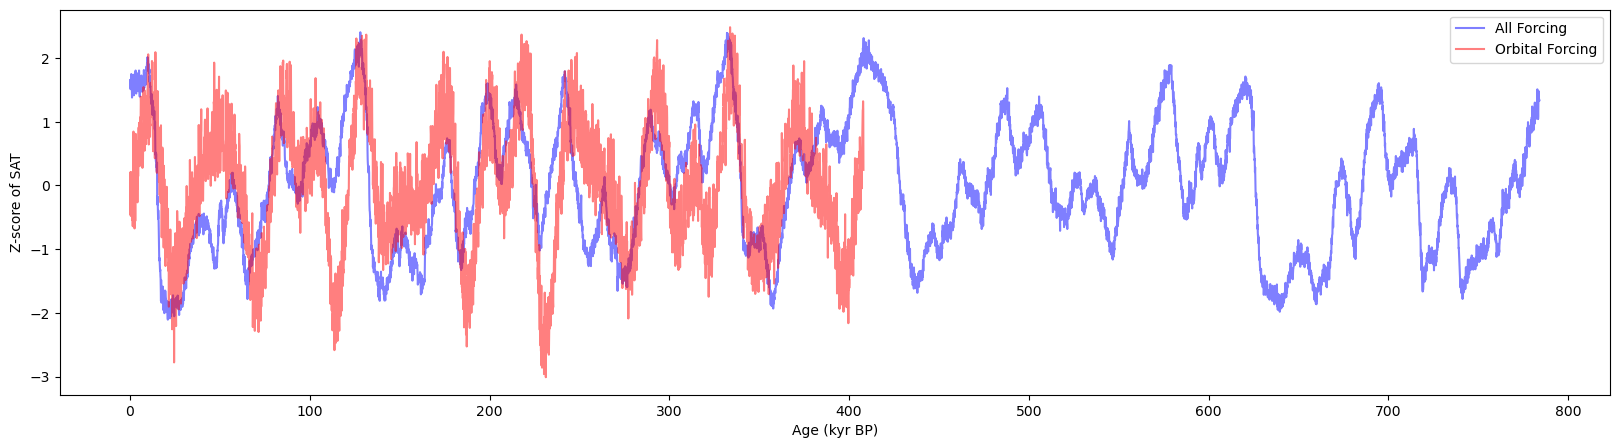

In [ ]:
# import xarray as xr

# ds_orb=xr.open_dataset(r"E:\loveclim_data\loveclim_se_orbital_only_atm.nc")
# ds_orb = ds_orb.rename({'t2m': 'sat'})
# # rename the time to age
# ds_orb = ds_orb.rename({'mtime': 'age'})



# ds_all = xr.open_dataset('E:/loveclim_data/loveclim_784k_atm.nc')

# ds_all = ds_all.rename({'t2m': 'sat'})
# # rename the time to age
# ds_all = ds_all.rename({'mtime': 'age'})

# import matplotlib.pyplot as plt
# from scipy.stats import zscore

# plt.figure(figsize=(20, 5))
# plt.plot(ds_all['age'].values, zscore(ds_all['sat'].isel(lat=30, lon=0).values), label='All Forcing', color='blue', alpha=0.5)
# plt.plot(ds_orb['age'].values, zscore(ds_orb['sat'].isel(lat=30, lon=0).values), label='Orbital Forcing', color='red', alpha=0.5)
# plt.xlabel('Age (kyr BP)')
# plt.ylabel('Z-score of SAT')
# # plt.title('Z-score of SAT at 30°N, 0°E')
# plt.legend()


# Data processing

Original age max: 408.0
Original age min: 0.1


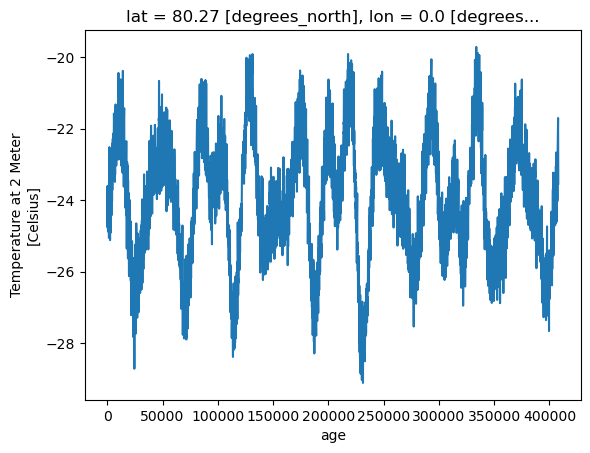

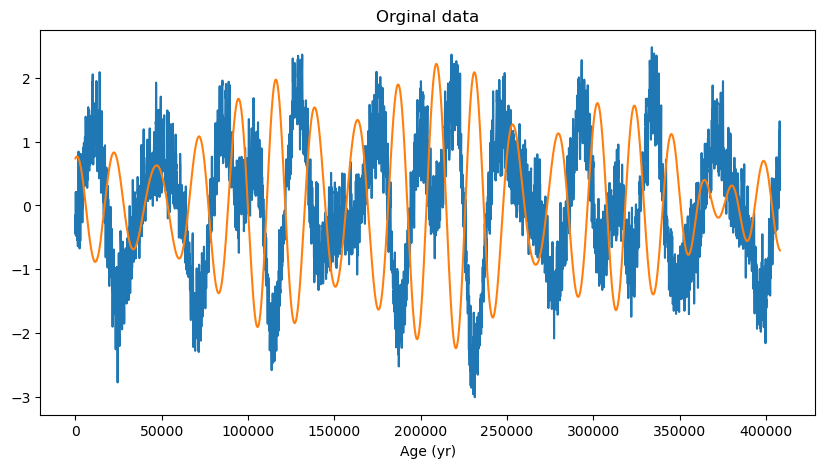

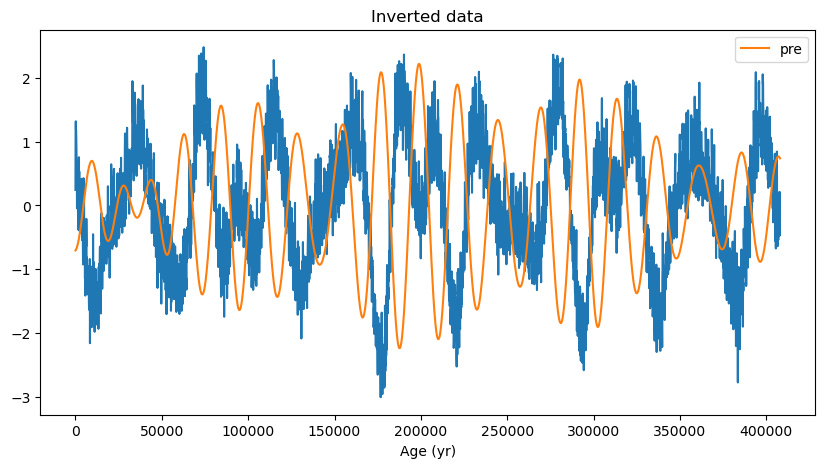

In [3]:
# import pre_800.csv from /inso_data
import pandas as pd

# Read the file into a DataFrame
df_pre = pd.read_csv(
    r"D:\VScode\Inso_LGMR\inso_data\pre_800.txt", 
    sep='\s+',       # '\s+' means "split on any whitespace"
    header=None,     # or specify a row number if there's a header
    engine='python'
)


df_pre.iloc[:, 0] = df_pre.iloc[:, 0].abs() * 1000

# Rename the columns
df_pre.columns = ['age', 'pre']

df_pre = df_pre[(df_pre['age'] >= 100) & (df_pre['age'] <= 408000)]



# load loveclim_se_orbital_only_atm.nc from E:\loveclim_data
import xarray as xr

ds=xr.open_dataset(r"E:\loveclim_data\loveclim_se_orbital_only_atm.nc")
ds

ds = ds.rename({'t2m': 'sat'})
# rename the time to age
ds = ds.rename({'mtime': 'age'})

print('Original age max:', ds['age'].max().values)
print('Original age min:', ds['age'].min().values)


# # multiply age by 1000
age_yr = ds['age'] * 1_000    
# age_yr = age_yr.max() - age_yr 
ds = ds.assign_coords(age=age_yr)                 



ds

# # # convert the sat to degrees C
# # ds['sat'] = ds['sat'] - 273.15

ds = ds[['sat']]
ds
ds['sat'].isel(lat=30, lon=0).plot()

# plot a record from the ds_sat at given lat and lon
import matplotlib.pyplot as plt
from scipy.stats import zscore

plt.figure(figsize=(10, 5))
plt.plot(ds['age'].values, zscore(ds['sat'].isel(lat=30, lon=0).values))
# plot the pre_800.csv data
plt.plot(df_pre['age'], zscore(df_pre['pre']), label='pre')
plt.title('Orginal data')
plt.xlabel('Age (yr)')



age_yr = age_yr.max() - age_yr                 
ds = ds.assign_coords(age=age_yr)
df_pre['age'] = df_pre['age'] * -1 + 408000

plt.figure(figsize=(10, 5))
plt.plot(ds['age'].values, zscore(ds['sat'].isel(lat=30, lon=0).values))
# plot the pre_800.csv data
plt.plot(df_pre['age'], zscore(df_pre['pre']), label='pre')
plt.title('Inverted data')
plt.xlabel('Age (yr)')
plt.legend()


In [45]:
df_pre.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4080 entries, 3920 to 7999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     4080 non-null   float64
 1   pre     4080 non-null   float64
dtypes: float64(2)
memory usage: 95.6 KB


# Ana for single time series: Smooth + resampling

Length of df_ccm (1 000-yr grid): 408


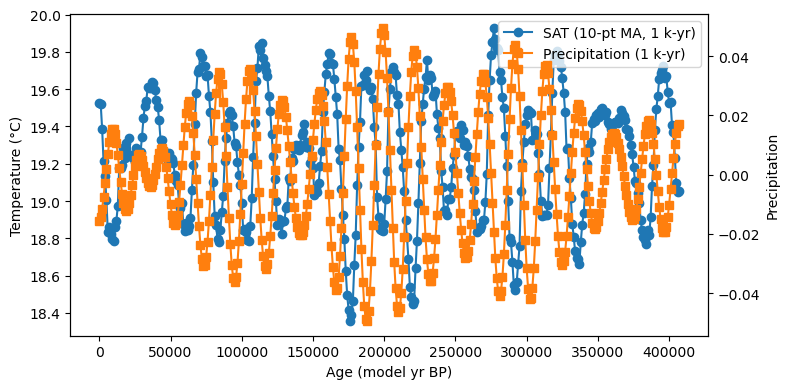

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pyEDM import CCM


# ------------------------------------------------------------------
# 1. centred moving–average helper  (unchanged)
# ------------------------------------------------------------------
def smooth_sat(ds: xr.Dataset, lat_val: float, lon_val: float,
               window: int = 10, var: str = "sat") -> pd.Series:
    raw = (ds[var]
           .sel(lat=lat_val, lon=lon_val, method="nearest")
           .to_series())
    return raw.rolling(window=window, center=True, min_periods=1).mean()

# ------------------------------------------------------------------
# 2. smooth SAT at (30 °N, 0 °E)
# ------------------------------------------------------------------
sat_smooth = smooth_sat(ds, lat_val=30, lon_val=0)

# make sure the two original age axes are the same
assert np.allclose(sat_smooth.index, df_pre["age"].values), "age axes differ!"

# ──────────────────────────────────────────────────────────────────
# 3. NEW: interpolate both series to 1 000-yr spacing
# ──────────────────────────────────────────────────────────────────
# a) build the target grid: nearest 1 000-yr boundaries within the data range
age_min = int(np.ceil( df_pre["age"].min() / 1000.0) * 1000)   # e.g. 4000
age_max = int(np.floor(df_pre["age"].max() / 1000.0) * 1000)   # e.g. 7000
age_1k  = np.arange(age_min, age_max + 1, 1000, dtype=int)

# b) interpolate (linear) onto that grid
sat_1k = pd.Series(
    np.interp(age_1k, sat_smooth.index.values, sat_smooth.values),
    index=age_1k, name="sat")

pre_1k = pd.Series(
    np.interp(age_1k, df_pre["age"].values, df_pre["pre"].values),
    index=age_1k, name="pre")

# c) assemble CCM input
df_ccm = pd.DataFrame({
    "age": age_1k,
    "sat": sat_1k.values,
    "pre": pre_1k.values
})

print("Length of df_ccm (1 000-yr grid):", len(df_ccm))   # should be ~4 points in your range

# ------------------------------------------------------------------
# 4. quick visual check  (now on the 1 000-yr grid)
# ------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(df_ccm["age"], df_ccm["sat"], marker="o", label="SAT (10-pt MA, 1 k-yr)")
ax1.set_xlabel("Age (model yr BP)")
ax1.set_ylabel("Temperature (°C)")
ax2 = ax1.twinx()
ax2.plot(df_ccm["age"], df_ccm["pre"], color="tab:orange",
         marker="s", label="Precipitation (1 k-yr)")
ax2.set_ylabel("Precipitation")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper right")
plt.tight_layout(); plt.show()



# CCM for single time series

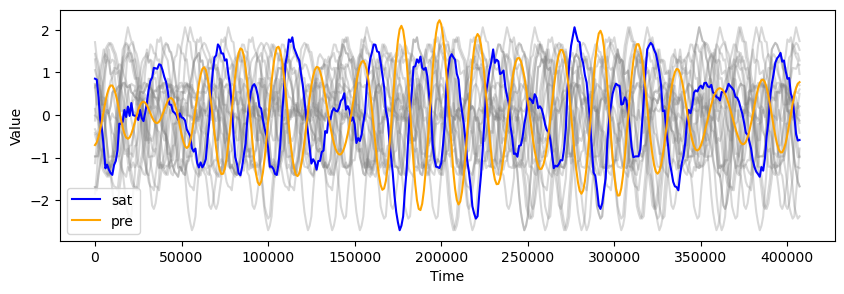

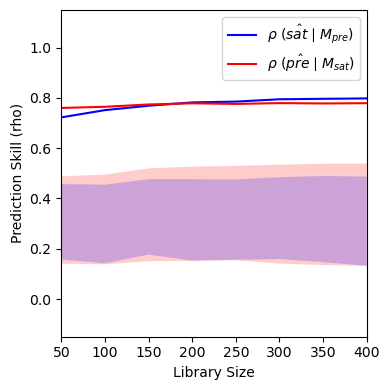

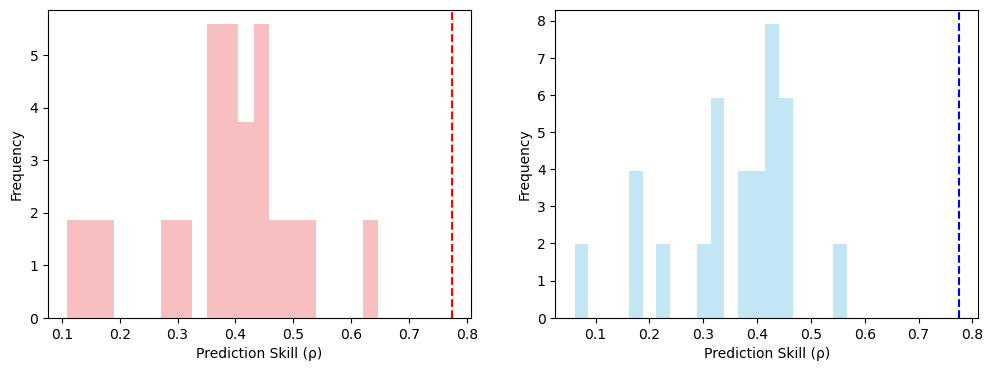

SAT xmap Pre causality? : True
Pre xmap SAT?          : True


In [7]:
from toolbox import significant_test as st
import importlib ; importlib.reload(st)

ccm_out, ensemble_ccm, (sig_satxmappre, sig_prexmapsat) = (
    st.ccm_significance_test_v2_df(
        df_input   = df_ccm,
        E          = 3,          # with only a handful of samples, keep E modest
        tau        = -1,         # likewise shorten τ
        n_ran      = 20,
        libSizes   = "50 100 150 200 250 300 350 400",    # max lib size ≤ (# points – E)
        Tp         = 0,
        sample     = 20,
        random     = True,
        showPlot   = True
    )
)

print("SAT xmap Pre causality? :", sig_satxmappre)
print("Pre xmap SAT?          :", sig_prexmapsat)


In [22]:
df_ccm.info

<bound method DataFrame.info of         age        sat       pre
0         0  26.804861 -0.015622
1      1000  26.812260 -0.014268
2      2000  26.804150 -0.011532
3      3000  26.805399 -0.007645
4      4000  26.801413 -0.002909
..      ...        ...       ...
403  403000  26.789871  0.005727
404  404000  26.773996  0.010453
405  405000  26.767666  0.014018
406  406000  26.761282  0.016308
407  407000  26.768314  0.017116

[408 rows x 3 columns]>

# Find the optimal Tp

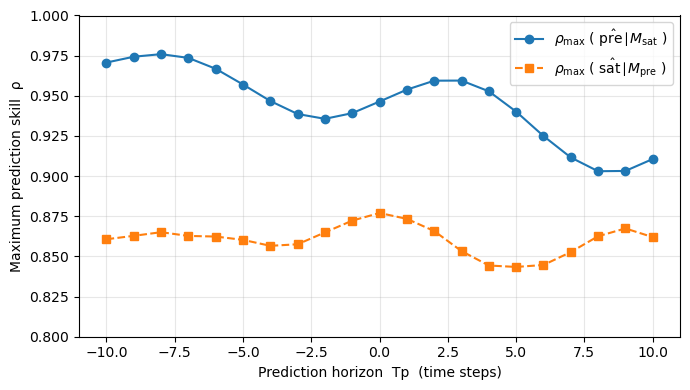

In [11]:

# sweep Tp from -10 to 10
Tp_vals      = np.arange(-10, 11, 1)
max_rho_sat2pre = []   # X➝Y  (sat ▸ pre)
max_rho_pre2sat = []   # Y➝X  (pre ▸ sat)

libSizes = "100 300"   # plenty of room with 4 000+ points

for Tp_val in Tp_vals:
    out = CCM(
        dataFrame   = df_ccm,
        E           = 5,
        tau         = -8,
        columns     = "sat",
        target      = "pre",
        libSizes    = libSizes,
        sample      = 20,
        random      = True,
        replacement = False,
        Tp          = Tp_val
    )
    # grab the *largest* rho at this Tp for each direction
    max_rho_sat2pre.append(out["sat:pre"].max())
    max_rho_pre2sat.append(out["pre:sat"].max())

# ──────────────────────────────────────────────────────────────────
# ◉  PLOT  ρmax  vs  Tp
# ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(Tp_vals, max_rho_sat2pre, "o-", label=r"$\rho_{\max}$ ( $\hat{\mathrm{pre}}\!\mid\!M_{\mathrm{sat}}$ )")
ax.plot(Tp_vals, max_rho_pre2sat, "s--", label=r"$\rho_{\max}$ ( $\hat{\mathrm{sat}}\!\mid\!M_{\mathrm{pre}}$ )")
# set y-axis limits to [0.6, 1]
ax.set_ylim(0.8, 1.0)
ax.set_xlabel("Prediction horizon  Tp  (time steps)")
ax.set_ylabel("Maximum prediction skill  ρ")
ax.axhline(0, color="k", lw=0.5)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


# Sliding window analysis

window   1/4 – mid-age   50000 yr | sig=True | ρ_max=0.66
window   2/4 – mid-age  150000 yr | sig=True | ρ_max=0.84
window   3/4 – mid-age  250000 yr | sig=True | ρ_max=0.84
window   4/4 – mid-age  350000 yr | sig=True | ρ_max=0.73


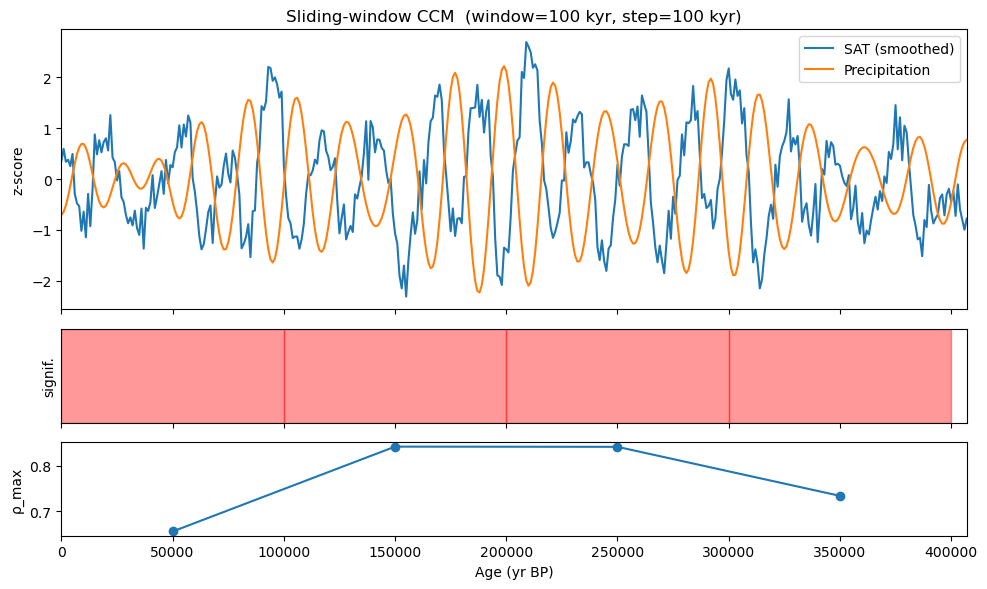

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from toolbox import significant_test as st
import importlib; importlib.reload(st)


WIN  = 100           # 40 points  → will be 40 kyr if dt = 1 kyr
STEP = 100           # 10 points  → 10 kyr if dt = 1 kyr
EMB  = 3
LAGS = -1
LIBSZ = "20 40"

# ------------------------------------------------------------------
# 0.  figure out the actual sampling interval
# ------------------------------------------------------------------
dt_yr = int(np.diff(df_ccm["age"][:2])[0])        # should be 1 000
win_yr  = WIN  * dt_yr
step_yr = STEP * dt_yr

# ------------------------------------------------------------------
# 1.  sliding-window CCM
# ------------------------------------------------------------------
starts  = np.arange(0, len(df_ccm) - WIN + 1, STEP)
centres = df_ccm["age"].iloc[starts + WIN//2].values

sig_vec = np.zeros(len(starts), dtype=bool)
rho_vec = np.full(len(starts), np.nan)

for k, s in enumerate(starts):
    df_win = df_ccm.iloc[s : s + WIN].reset_index(drop=True)

    ccm_out, _, (sig_sat2pre, _) = st.ccm_significance_test_v2_df(
        df_input = df_win,
        E        = EMB,
        tau      = LAGS,
        n_ran    = 50,
        libSizes = LIBSZ,
        sample   = 20,
        random   = True,
        showPlot = False
    )

    sig_vec[k] = sig_sat2pre
    rho_vec[k] = ccm_out["X:Y"].max()

    print(f"window {k+1:>3}/{len(starts)} – mid-age {centres[k]:>7} yr "
          f"| sig={sig_sat2pre} | ρ_max={rho_vec[k]:.2f}")

# ------------------------------------------------------------------
# 2.  3×1 figure  (height ratio 3 : 1 : 1)
# ------------------------------------------------------------------
fig, (ax_ts, ax_sig, ax_rho) = plt.subplots(
    3, 1, figsize=(10, 6),
    sharex=True,
    gridspec_kw=dict(height_ratios=[3, 1, 1])
)

# top – SAT & PRE (z-scored for clarity)
ax_ts.plot(df_ccm["age"], zscore(df_ccm["sat"]), label="SAT (smoothed)")
ax_ts.plot(df_ccm["age"], zscore(df_ccm["pre"]), label="Precipitation")
ax_ts.set_ylabel("z-score")
ax_ts.legend(loc="upper right")
ax_ts.set_title(f"Sliding-window CCM  (window={win_yr/1000:.0f} kyr, step={step_yr/1000:.0f} kyr)")

# middle – shade windows with significant causality
for centre, sig in zip(centres, sig_vec):
    if sig:
        ax_sig.axvspan(centre - win_yr/2, centre + win_yr/2,
                       color="red", alpha=0.4)
ax_sig.set_ylabel("signif.")
ax_sig.set_yticks([])
ax_sig.set_ylim(0, 1)

# bottom – ρ_max
ax_rho.plot(centres, rho_vec, marker="o")  
ax_rho.set_ylabel("ρ_max")
ax_rho.set_xlabel("Age (yr BP)")

# set the x-axis limits to the range of the data
ax_rho.set_xlim(df_ccm["age"].min(), df_ccm["age"].max())


plt.tight_layout()
plt.show()


# Ana for the global: generate smoothed and interpolated data

In [13]:
import os, pathlib
import xarray as xr
import pandas as pd
import numpy as np


WIN        = 10       # centred moving-average window (age-steps)
STEP       = 1000     # resample interval [yr]
OUTDIR     = pathlib.Path("output")
OUTDIR.mkdir(exist_ok=True)

def preprocess_dataset(ds: xr.Dataset,
                       df_pre: pd.DataFrame,
                       win: int   = WIN,
                       step: int  = STEP,
                       var: str   = "sat") -> pathlib.Path:
    """
    ① smooth `var` with a centred `win`-point MA  
    ② linearly interpolate to a regular `step`-year grid  
    ③ add a 1-D resampled precipitation series  
    ④ write the result to /outputs/ and return the file path
    """
    # ① rolling mean (keeps edges with min_periods=1)
    sat_smooth = (ds[var]
                  .rolling(age=win, center=True, min_periods=1)
                  .mean())

    # ② common age grid (inclusive)
    a_min = int(np.ceil (ds.age.min().item() / step) * step)
    a_max = int(np.floor(ds.age.max().item() / step) * step)
    new_age = np.arange(a_min, a_max + 1, step, dtype=int)

    sat_interp = sat_smooth.interp(age=new_age)

    # ③ resample precipitation (1-D)
    pre_ser  = df_pre.set_index("age")["pre"]
    pre_1k   = np.interp(new_age, pre_ser.index.values, pre_ser.values)

    out_ds = xr.Dataset(
        data_vars = dict(
            sat = (("age", "lat", "lon"), sat_interp.data),
            pre = (("age",),              pre_1k)            # broadcast-free 1-D var
        ),
        coords    = dict(
            age = new_age,
            lat = ds.lat,
            lon = ds.lon,
        ),
        attrs     = dict(
            source      = "original ds + df_pre",
            smoothing   = f"{win}-step centred MA",
            resampling  = f"{step}-yr linear",
        )
    )

    fpath = OUTDIR / f"sat_smooth{win}_interp{step}yr.nc"
    out_ds.to_netcdf(fpath)
    return fpath

# run it once – produces ≈ 10 MB file for 32×64×(∼5 ages)
nc_file = preprocess_dataset(ds, df_pre)
print("written:", nc_file)


written: output\sat_smooth10_interp1000yr.nc


# Plot significant map

Launching CCM on 2048 grid-points with all CPUs …


100%|██████████| 2048/2048 [10:03<00:00,  3.39it/s]


CCM sweep complete.



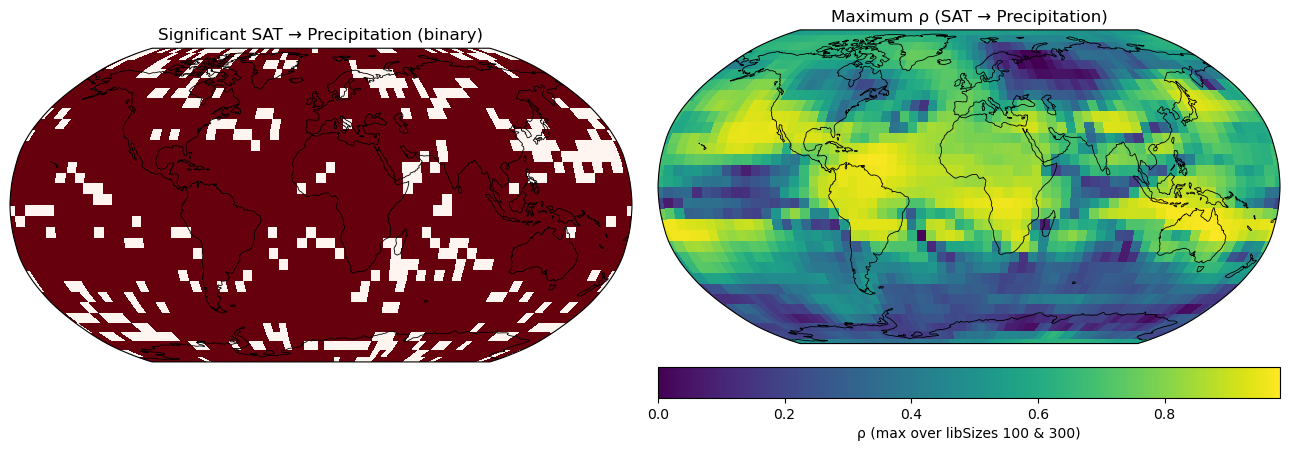

In [49]:
import xarray as xr, numpy as np, pandas as pd
from joblib import Parallel, delayed
from tqdm import tqdm
import cartopy.crs as ccrs, matplotlib.pyplot as plt
from toolbox import significant_test as st
import importlib; importlib.reload(st)

# how many workers?  -1 means “all logical cores”
N_JOBS = -1

# path from the preprocessing stage
ds_proc = xr.open_dataset(nc_file)
age     = ds_proc.age.values
pre_1k  = ds_proc["pre"].values

lat_vals, lon_vals = ds_proc.lat.values, ds_proc.lon.values
nlat, nlon = len(lat_vals), len(lon_vals)

# ──────────────────────────────────────────────────────────────────
# 1.  worker function – runs CCM on a single grid-point
#     (i,j) index   →   (i, j, sig_bool, rho_max)
# ──────────────────────────────────────────────────────────────────
def ccm_worker(i, j):
    sat_series = ds_proc["sat"][:, i, j].values
    df_ccm = pd.DataFrame(
        {"age": age, "sat": sat_series, "pre": pre_1k}
    )
    try:
        ccm_out, _, (sig_sat2pre, _) = st.ccm_significance_test_v2_df(
            df_input = df_ccm,
            E        = 3,
            tau      = -1,
            n_ran    = 20,
            libSizes = "100 300",
            sample   = 20,
            random   = True,
            showPlot = False
        )
        rho_max = ccm_out["X:Y"].max()
    except Exception as e:
        # return “not significant” and NaN rho
        sig_sat2pre, rho_max = False, np.nan
    return i, j, sig_sat2pre, rho_max

# ──────────────────────────────────────────────────────────────────
# 2.  parallel map over all (lat, lon) pairs
# ──────────────────────────────────────────────────────────────────
tasks = [(i, j) for i in range(nlat) for j in range(nlon)]

print(f"Launching CCM on {len(tasks)} grid-points "
      f"with {N_JOBS if N_JOBS>0 else 'all'} CPUs …")

results = Parallel(n_jobs=N_JOBS, backend="loky")(
    delayed(ccm_worker)(i, j) for i, j in tqdm(tasks)
)

# ──────────────────────────────────────────────────────────────────
# 3.  assemble the results into 2-D DataArrays
# ──────────────────────────────────────────────────────────────────
sig_arr = np.zeros((nlat, nlon), dtype=bool)
rho_arr = np.full((nlat, nlon), np.nan)

for i, j, sig, rho in results:
    sig_arr[i, j] = sig
    rho_arr[i, j] = rho

sig_map = xr.DataArray(sig_arr, coords=dict(lat=lat_vals, lon=lon_vals),
                       name="sig_sat2pre")
rho_map = xr.DataArray(rho_arr, coords=dict(lat=lat_vals, lon=lon_vals),
                       name="rho_max_sat2pre")

print("CCM sweep complete.\n")

# ──────────────────────────────────────────────────────────────────
# 4.  Robinson plots – binary & continuous
# ──────────────────────────────────────────────────────────────────
proj = ccrs.Robinson()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                subplot_kw=dict(projection=proj))

# (a) significance
pcm1 = ax1.pcolormesh(sig_map.lon, sig_map.lat, sig_map,
                      transform=ccrs.PlateCarree(),
                      cmap=plt.cm.Reds, vmin=0, vmax=1)
ax1.coastlines(linewidth=0.6)
ax1.set_title("Significant SAT → Precipitation (binary)")

# (b) max-rho
pcm2 = ax2.pcolormesh(rho_map.lon, rho_map.lat, rho_map,
                      transform=ccrs.PlateCarree(),
                      cmap="viridis",
                      vmin=0, vmax=np.nanmax(rho_map))
ax2.coastlines(linewidth=0.6)
ax2.set_title("Maximum ρ (SAT → Precipitation)")

fig.colorbar(pcm2, ax=ax2, orientation="horizontal", pad=0.05,
             label="ρ (max over libSizes 100 & 300)")
plt.tight_layout()
plt.show()
